In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pickle
import numpy as np
import joblib

In [4]:
file_path='transposed_marathwada_dataset.csv'
target_col='level'

In [5]:
df = pd.read_csv(file_path)
df.shape

(2652, 12)

In [6]:
df.columns

Index(['dem', 'dist_to_water', 'flow_acc', 'geom', 'lulc', 'ndwi', 'rain',
       'runoff_coeff', 'slope', 'soilTx', 'soil_moisture', 'level'],
      dtype='object')

In [7]:
X = df.drop([target_col,'dem'], axis=1)
y = df[target_col]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
mlp = MLPClassifier(
    hidden_layer_sizes=(32,16),  
    activation='relu',           
    solver='adam',               
    alpha=0.01,                 
    max_iter=300,                
    early_stopping=True,       
    validation_fraction=0.1,   
    n_iter_no_change=10,       
    random_state=42
)

In [13]:
mlp.fit(X_train_scaled, y_train)

MLPClassifier(alpha=0.01, early_stopping=True, hidden_layer_sizes=(32, 16),
              max_iter=300, random_state=42)

In [21]:
joblib.dump(mlp, 'mlp_model.joblib')
joblib.dump(scaler,'mlp_scaler.joblib')


['mlp_scaler.joblib']

In [14]:
y_pred = mlp.predict(X_test_scaled)

In [15]:
print("Evaluation on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Overfitting Check
print("\nOverfitting Check:")
print("Train Accuracy:", mlp.score(X_train_scaled, y_train))
print("Test Accuracy:", mlp.score(X_test_scaled, y_test))

Evaluation on Test Set:
Accuracy: 0.9717514124293786

Classification Report:
               precision    recall  f1-score   support

           1       0.96      1.00      0.98        50
           2       0.97      0.98      0.97       123
           3       0.99      0.94      0.97       119
           4       0.97      0.96      0.97       119
           5       0.96      1.00      0.98       120

    accuracy                           0.97       531
   macro avg       0.97      0.97      0.97       531
weighted avg       0.97      0.97      0.97       531


Overfitting Check:
Train Accuracy: 0.9585101367279585
Test Accuracy: 0.9717514124293786


In [16]:
print("Number of iterations run:", mlp.n_iter_)
print("Final training loss:", mlp.loss_)

Number of iterations run: 61
Final training loss: 0.12899677636825907


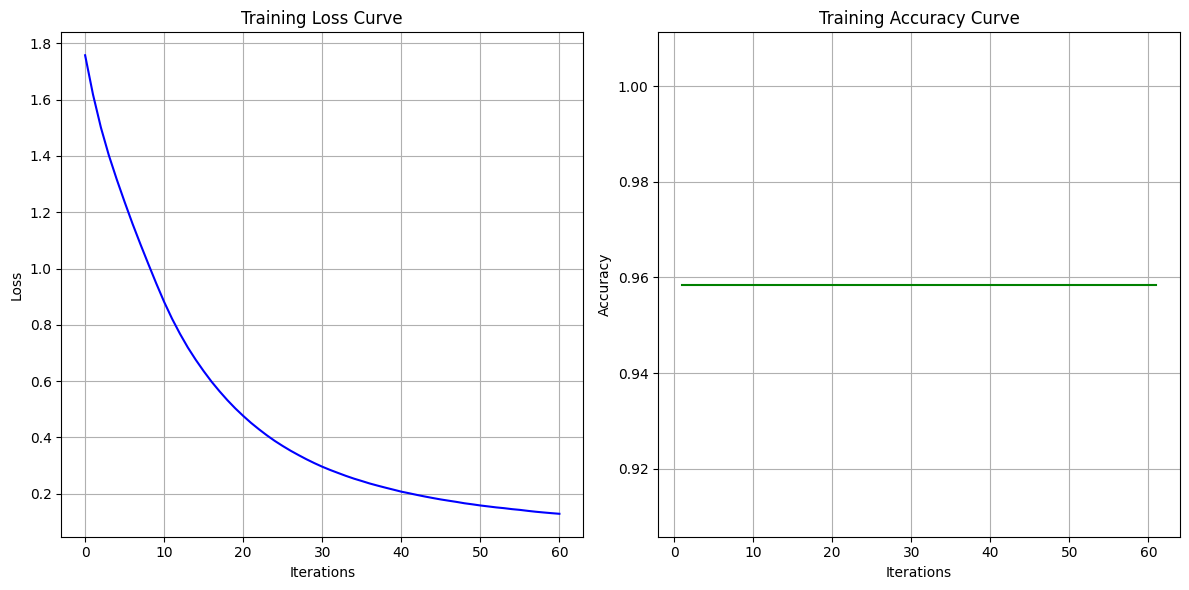

In [17]:
plt.figure(figsize=(12, 6))

# Plot the training loss over iterations
plt.subplot(1, 2, 1)
plt.plot(mlp.loss_curve_, label="Training Loss", color="blue")
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)

# Plot the training accuracy over iterations
# We will need to manually compute the accuracy at each iteration
train_accuracies = [accuracy_score(y_train, mlp.predict(X_train_scaled)) for _ in range(1, mlp.n_iter_+1)]

plt.subplot(1, 2, 2)
plt.plot(range(1, mlp.n_iter_ + 1), train_accuracies, label="Training Accuracy", color="green")
plt.title("Training Accuracy Curve")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.grid(True)

# Show the plots
plt.tight_layout()
plt.show()